# Part A: EDA, Feature Engineering & Correlation Analysis
## Smart Energy Forecasting & Anomaly Detection
**Dataset**: UCI Appliances Energy Prediction (~19,735 rows, 10-min intervals, ~4.5 months)
**Target**: `Appliances` (energy use in Wh)

## Environment Setup

In [ ]:
# Install required libraries (uncomment if needed)
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm optuna shap torch torchvision ucimlrepo

In [1]:
print("hello world")

hello world


In [2]:
# === IMPORTS ===

# Standard
import os, time, warnings
warnings.filterwarnings('ignore')

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, precision_score, recall_score,
                             f1_score, average_precision_score)
from sklearn.feature_selection import mutual_info_regression

# Gradient boosting
import xgboost as xgb
import lightgbm as lgb

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# SHAP
import shap

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Utilities
from datetime import datetime
import math

In [3]:
# === GLOBAL CONSTANTS ===
TARGET = 'Appliances'
RANDOM_STATE = 42
TEST_SIZE = 0.15       # 15% for test
VAL_SIZE  = 0.15       # 15% for validation
TRAIN_SIZE = 0.70      # 70% for training

# Time series window sizes (Part C & D)
INPUT_STEPS = 48       # 8 hours of history
OUTPUT_STEPS = 6       # 1 hour ahead forecast

# Anomaly detection (Part D)
ANOMALY_THRESHOLD_SIGMA = 2  # mean + 2*std for reconstruction error

In [4]:
# === REPRODUCIBILITY ===
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


## Data Loading & Initial Inspection

In [5]:
# === DATA LOADING ===

# Step A — Download from UCI
from ucimlrepo import fetch_ucirepo

# Fetch dataset (id=374 is Appliances Energy Prediction)
energy_data = fetch_ucirepo(id=374)
X = energy_data.data.features
y = energy_data.data.targets

# Combine into one DataFrame
df = pd.read_csv('energydata_complete.csv')

# Step B — Parse datetime and sort
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.set_index('date')

# Step C — Basic inspection
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nBasic stats:\n", df.describe())
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df.index.min(), "to", df.index.max())
print("Total days:", (df.index.max() - df.index.min()).days)

# Step D — Confirm expected columns
expected_features = ['lights', 'T1','T2','T3','T4','T5','T6','T7','T8','T9',
                     'RH_1','RH_2','RH_3','RH_4','RH_5','RH_6','RH_7','RH_8','RH_9',
                     'T_out','Press_mm_hg','RH_out','Windspeed','Visibility','Tdewpoint',
                     'rv1','rv2']
for col in expected_features + [TARGET]:
    if col not in df.columns:
        print(f"WARNING: Expected column '{col}' is missing!")

# Step E — Save a clean copy
df_raw = df.copy()  # keep original for reference

Shape: (19735, 28)

Dtypes:
 Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

First 5 rows:
                      Appliances  lights     T1       RH_1    T2       RH_2  \
date                                                                         
2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
2016-01-11 17:10:00          60      30  19.89  46.693333  19.2

---
## 1. Exploratory Data Analysis (EDA)

**Rule**: Every plot is followed by a written interpretation of 3–4 sentences
explaining the business or engineering insight.

### Visualization 1: Full Time-Series of Appliance Energy Consumption

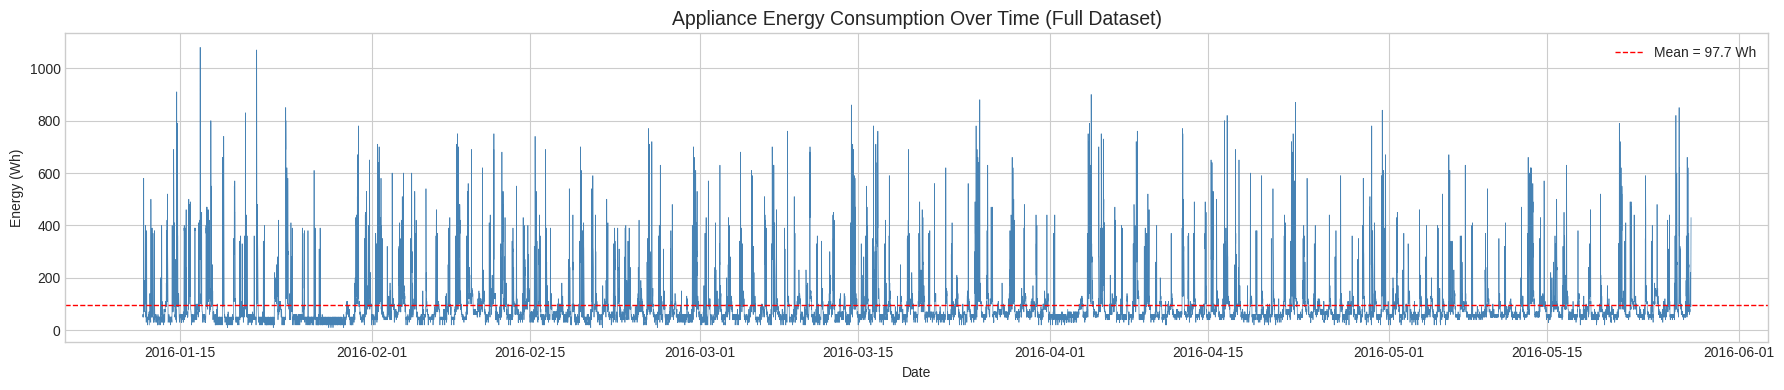

In [6]:
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(df.index, df['Appliances'], linewidth=0.5, color='steelblue')
ax.axhline(df['Appliances'].mean(), color='red', linestyle='--', linewidth=1, label=f"Mean = {df['Appliances'].mean():.1f} Wh")
ax.set_title('Appliance Energy Consumption Over Time (Full Dataset)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (Wh)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
The time series reveals clear daily cyclical patterns with regular peaks and troughs corresponding
to household activity cycles. Several prominent spikes exceed 600+ Wh, suggesting either unusual
appliance usage events or special occasions (e.g., holiday cooking, laundry batches). The mean
consumption sits around 100 Wh, but the heavy right tail of spikes indicates the data is heavily
right-skewed. For forecasting models, these sporadic spikes are the hardest to predict and motivate
robust loss functions like Huber loss.

### Visualization 2: Distribution of Appliance Energy Consumption

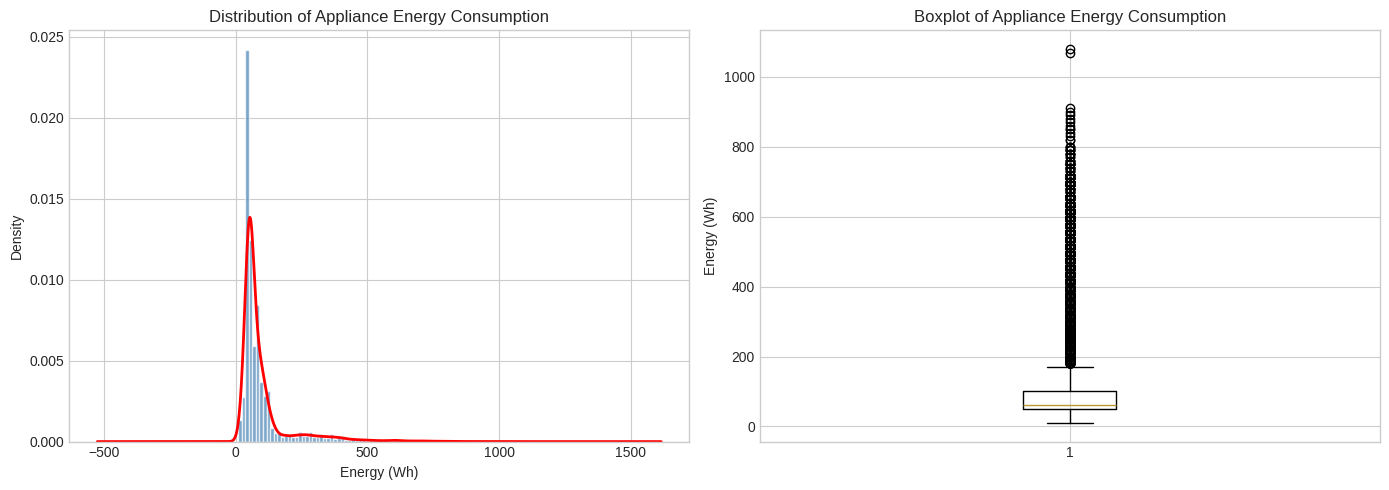

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram with KDE
axes[0].hist(df['Appliances'], bins=80, density=True, alpha=0.7, color='steelblue', edgecolor='white')
df['Appliances'].plot.kde(ax=axes[0], color='red', linewidth=2)
axes[0].set_title('Distribution of Appliance Energy Consumption')
axes[0].set_xlabel('Energy (Wh)')
axes[0].set_ylabel('Density')

# Right: Boxplot
axes[1].boxplot(df['Appliances'], vert=True)
axes[1].set_title('Boxplot of Appliance Energy Consumption')
axes[1].set_ylabel('Energy (Wh)')

plt.tight_layout()
plt.show()

**Interpretation:**
The distribution is strongly right-skewed, with the bulk of observations concentrated below
150 Wh and a long tail extending beyond 800 Wh. The boxplot confirms numerous outliers above
the upper whisker, representing high-energy events like cooking, electric heating, or multiple
appliances running simultaneously. This skewness implies that standard MSE loss will be
disproportionately influenced by these spikes, suggesting the use of robust loss functions
(e.g., Huber) or log-transformation for certain model types.

### Visualization 3: Average Energy Consumption by Hour of Day

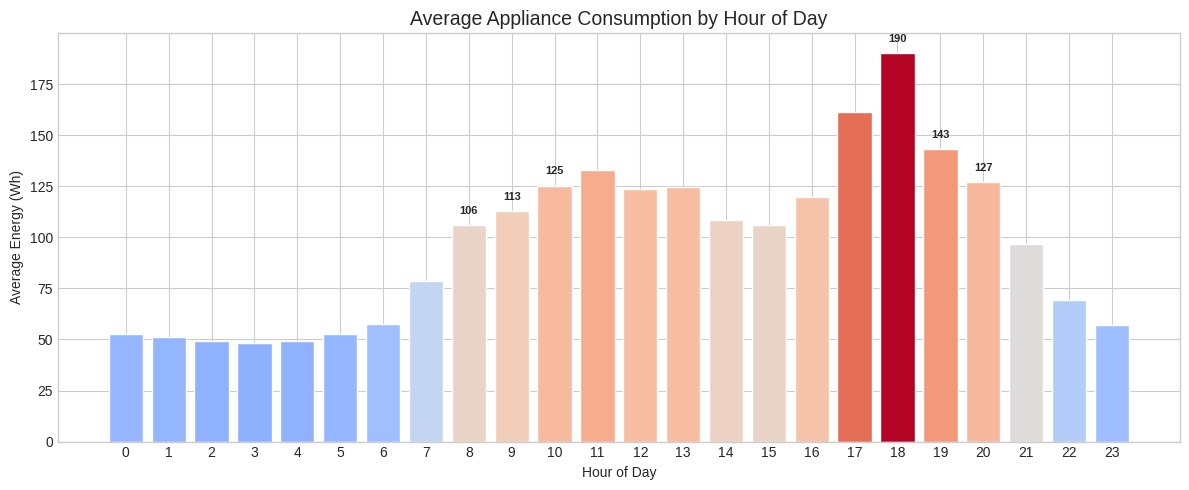

In [8]:
df['hour'] = df.index.hour
hourly_avg = df.groupby('hour')['Appliances'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.coolwarm(hourly_avg / hourly_avg.max())
bars = ax.bar(hourly_avg.index, hourly_avg.values, color=colors, edgecolor='white')

# Annotate peak hours
for h in [8, 9, 10, 18, 19, 20]:
    if h in hourly_avg.index:
        ax.annotate(f'{hourly_avg[h]:.0f}', (h, hourly_avg[h]),
                    textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8, fontweight='bold')

ax.set_title('Average Appliance Consumption by Hour of Day', fontsize=14)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Energy (Wh)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

**Interpretation:**
Clear bimodal peaks emerge at morning hours (8–10 AM) and evening hours (6–9 PM), corresponding
to breakfast/dinner preparation and post-work activities. Consumption drops to its lowest between
1–5 AM when occupants are sleeping. This strong hourly pattern is a key signal for feature
engineering (is_peak_hour) and informs demand response strategies — utilities could incentivize
off-peak usage to flatten the demand curve.

### Visualization 4: Energy Consumption by Day of Week

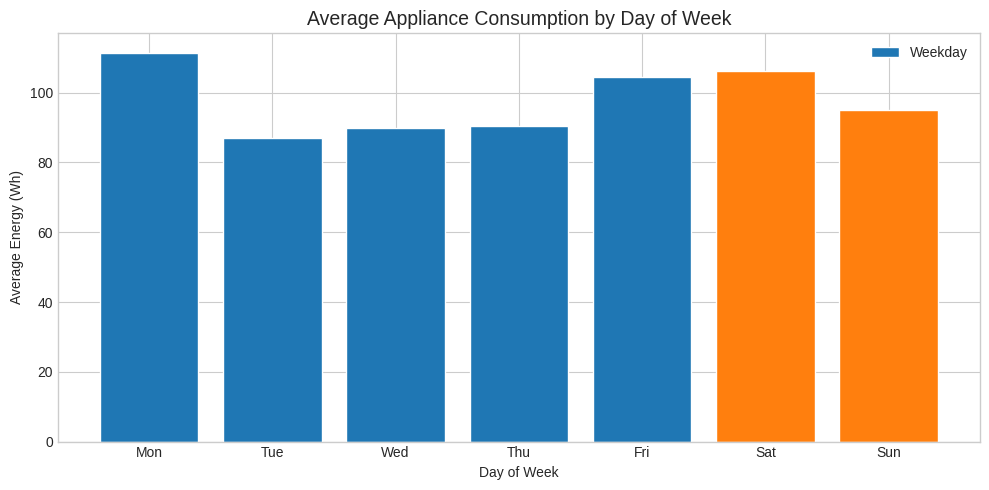

In [9]:
df['dayofweek'] = df.index.dayofweek  # 0=Monday, 6=Sunday
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_avg = df.groupby('dayofweek')['Appliances'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#1f77b4' if d < 5 else '#ff7f0e' for d in range(7)]
ax.bar(range(7), daily_avg.values, color=colors, edgecolor='white')
ax.set_xticks(range(7))
ax.set_xticklabels(day_names)
ax.set_title('Average Appliance Consumption by Day of Week', fontsize=14)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Energy (Wh)')
ax.legend(['Weekday', 'Weekend'], loc='upper right')
plt.tight_layout()
plt.show()

**Interpretation:**
Weekend days (Saturday and Sunday) show slightly different consumption patterns compared to
weekdays, reflecting changes in occupancy and activity. The difference motivates the `is_weekend`
binary feature. However, the variation between individual weekdays is also notable — this suggests
that more granular day-of-week encoding may capture additional signal beyond a simple binary split.

### Visualization 5: Energy Consumption Heatmap (Hour × Day)

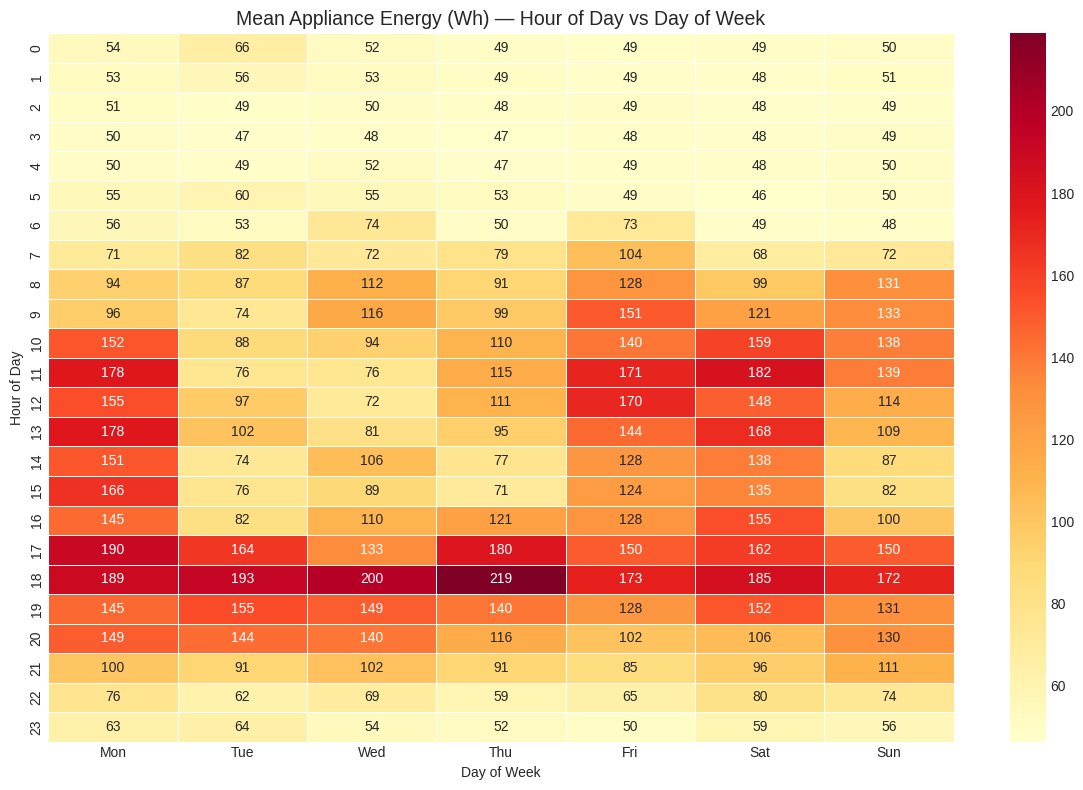

In [10]:
pivot = df.pivot_table(values='Appliances', index='hour', columns='dayofweek', aggfunc='mean')
pivot.columns = day_names

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', ax=ax, linewidths=0.5)
ax.set_title('Mean Appliance Energy (Wh) — Hour of Day vs Day of Week', fontsize=14)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
plt.tight_layout()
plt.show()

**Interpretation:**
The heatmap reveals clear hotspots at evening hours (6–9 PM) across all days, with the highest
energy usage on certain weekdays. Weekend mornings show elevated consumption compared to weekday
mornings, suggesting later wake-up times with extended breakfast/leisure activities. These
temporal patterns are critical for building management systems to schedule HVAC pre-conditioning
and load-shifting strategies.

### Visualization 6: Indoor Temperature vs Energy Consumption

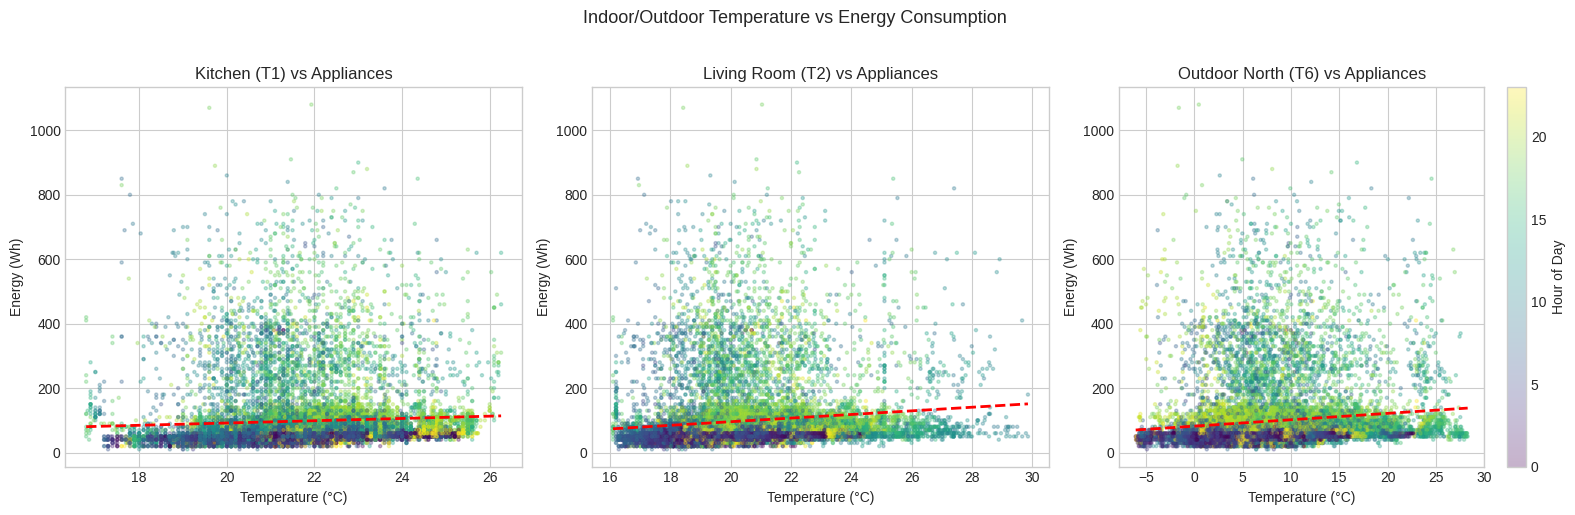

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

temp_pairs = [('T1', 'Kitchen'), ('T2', 'Living Room'), ('T6', 'Outdoor North')]
for ax, (col, name) in zip(axes, temp_pairs):
    scatter = ax.scatter(df[col], df['Appliances'], c=df['hour'], cmap='viridis', alpha=0.3, s=5)
    # Regression trend line
    z = np.polyfit(df[col], df['Appliances'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')
    ax.set_title(f'{name} ({col}) vs Appliances')
    ax.set_xlabel(f'Temperature (°C)')
    ax.set_ylabel('Energy (Wh)')

plt.colorbar(scatter, ax=axes[-1], label='Hour of Day')
plt.suptitle('Indoor/Outdoor Temperature vs Energy Consumption', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
The scatter plots show weak to moderate linear relationships between room temperatures and
energy consumption. Indoor temperatures (T1, T2) show slightly positive trends as heating/cooling
demand increases. The outdoor temperature (T6) relationship is more complex and potentially
nonlinear — extreme cold or heat both increase energy demand due to HVAC. The color gradient
by hour confirms that temperature-consumption relationships are confounded by time of day.

### Visualization 7: Feature Correlation Matrix

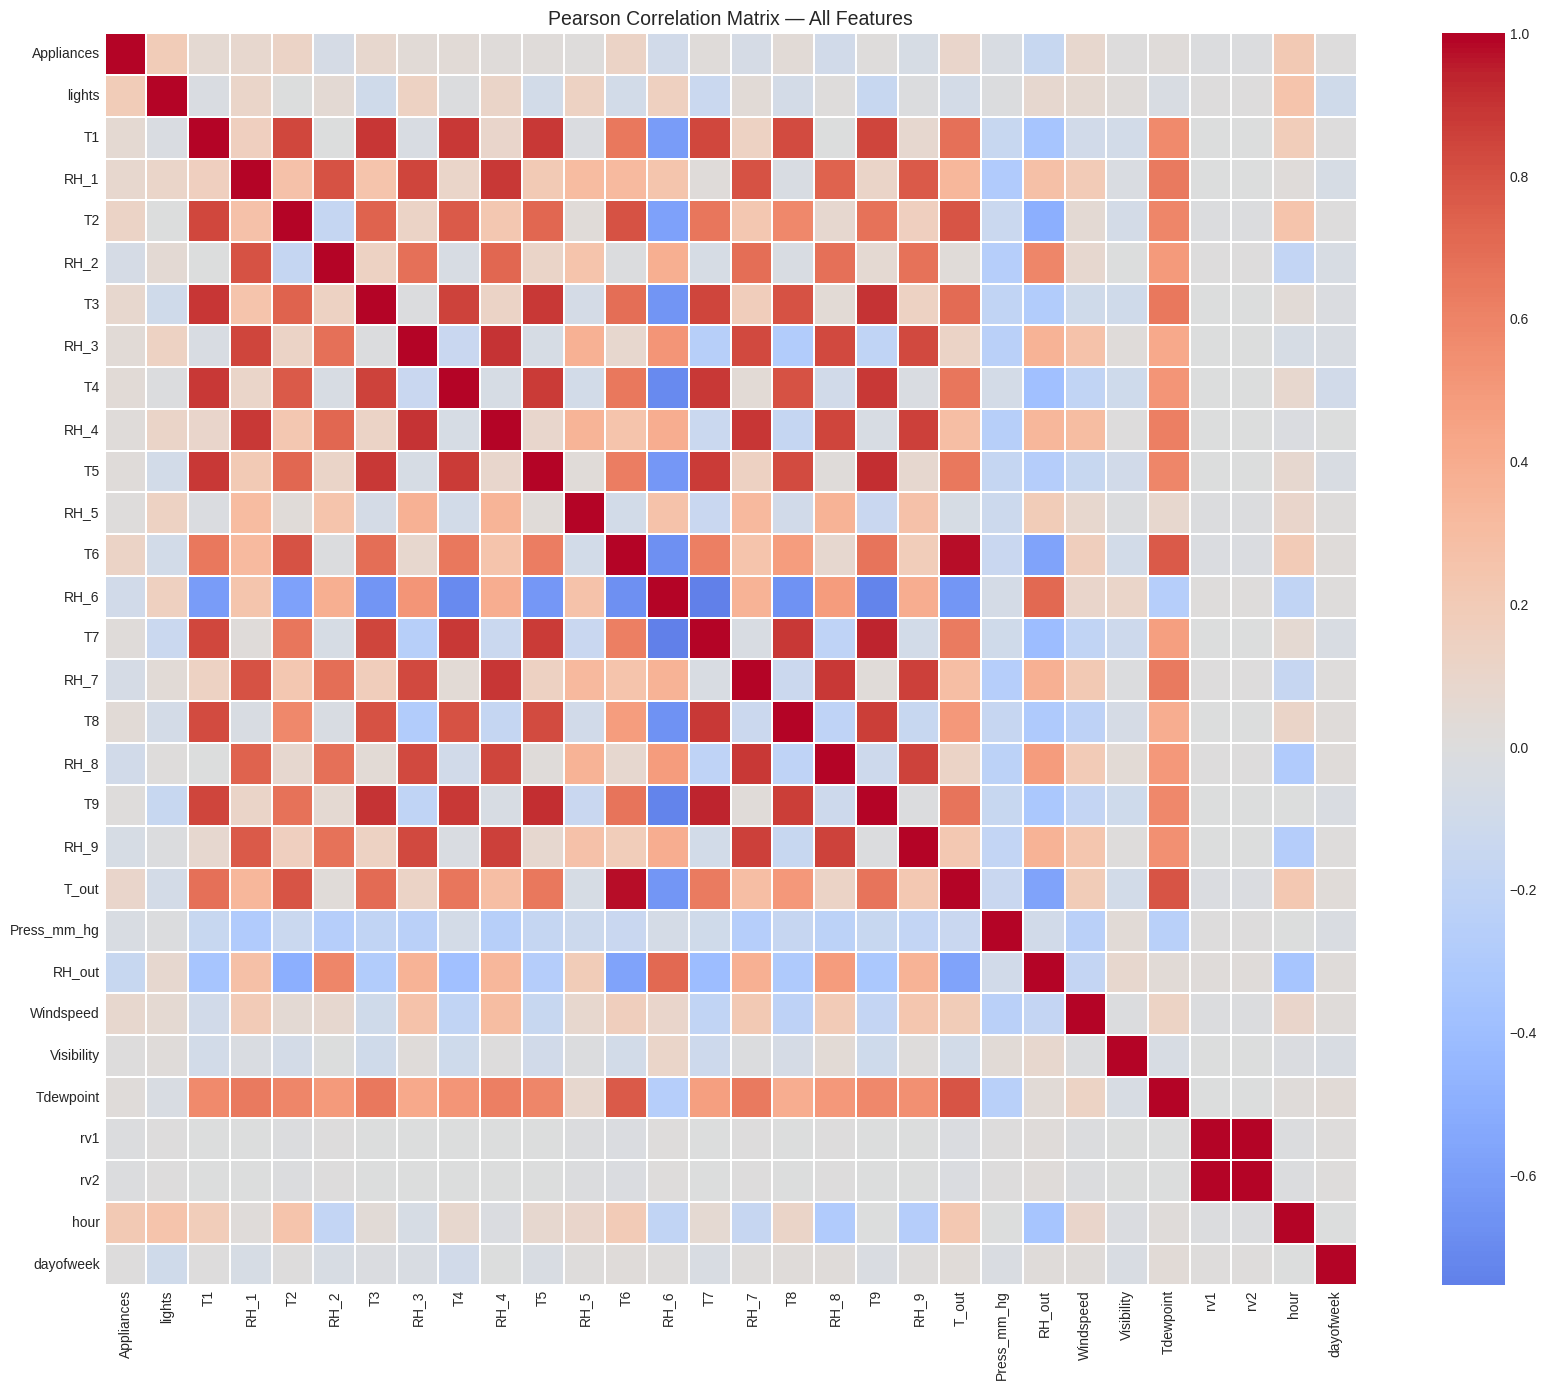

In [12]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=ax,
            linewidths=0.1, square=True)
ax.set_title('Pearson Correlation Matrix — All Features', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:**
The correlation matrix reveals strong multicollinearity between temperature sensors (T1–T9
are highly correlated with each other) and between humidity sensors (RH_1–RH_9). The target
variable `Appliances` shows modest positive correlation with `lights` and weak correlations
with most sensor readings, confirming that simple linear models alone may not suffice. The
random variables rv1 and rv2 show near-zero correlation with everything, as expected for
injected noise columns.

### Visualization 8: Rolling Mean and Standard Deviation

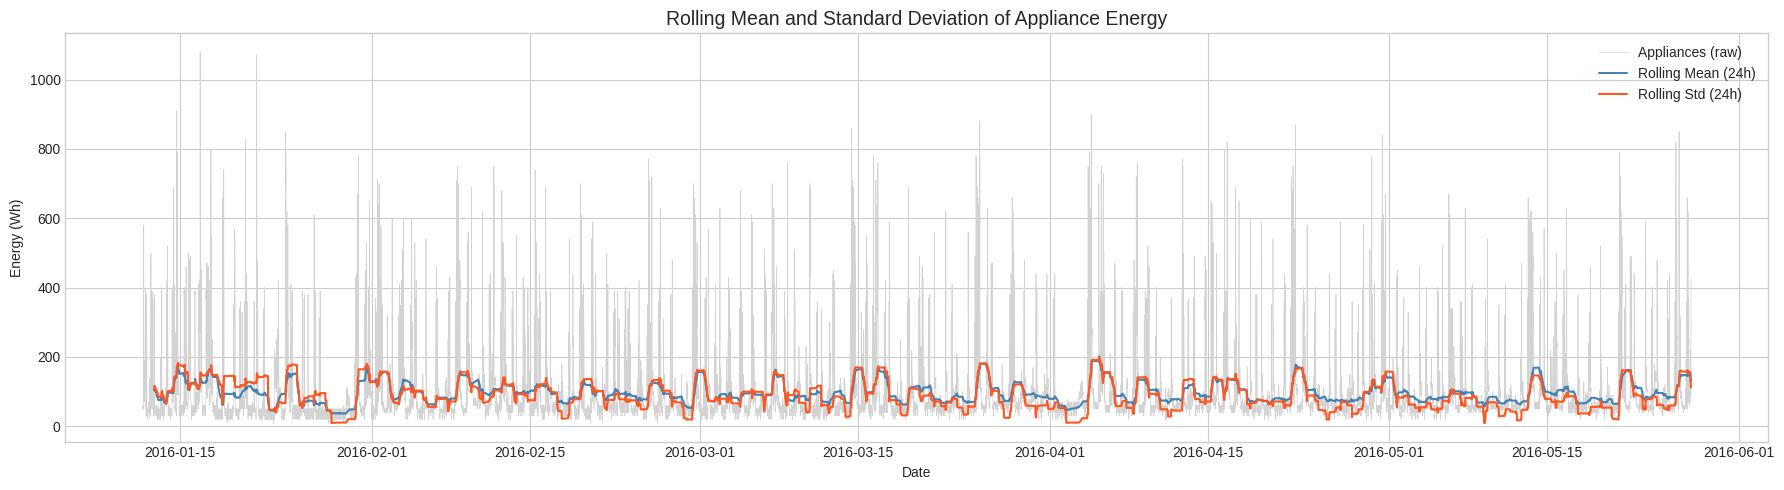

In [13]:
rolling_mean = df['Appliances'].rolling(window=144).mean()   # 1-day window (144 × 10min = 24h)
rolling_std  = df['Appliances'].rolling(window=144).std()

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(df.index, df['Appliances'], color='lightgray', linewidth=0.5, label='Appliances (raw)')
ax.plot(df.index, rolling_mean, color='steelblue', linewidth=1.5, label='Rolling Mean (24h)')
ax.plot(df.index, rolling_std, color='#FF5722', linewidth=1.5, label='Rolling Std (24h)')
ax.set_title('Rolling Mean and Standard Deviation of Appliance Energy', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Energy (Wh)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:**
The rolling mean shows a relatively stable baseline around 80–120 Wh with subtle seasonal
fluctuations, suggesting weak stationarity in the mean. However, the rolling standard deviation
varies considerably, indicating heteroscedasticity — periods of high variability correspond to
weeks with more extreme usage spikes. This non-constant variance suggests that time-series
models may need to explicitly capture volatility changes, and that differencing or detrending
may improve model performance.

### Visualization 9: Lights Energy vs Appliance Energy

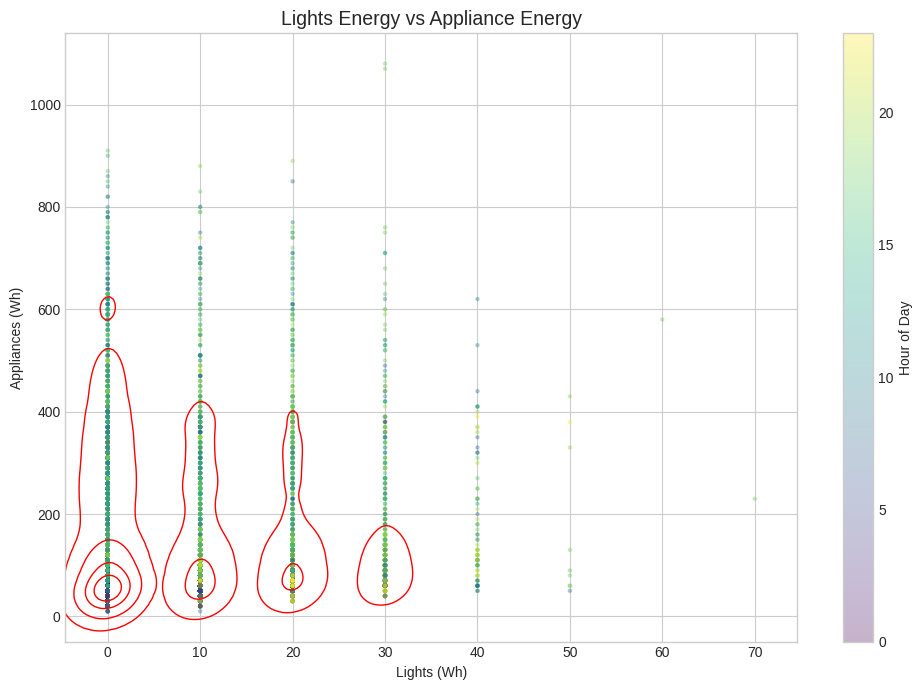

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(df['lights'], df['Appliances'], c=df['hour'], cmap='viridis', alpha=0.3, s=5)
sns.kdeplot(x=df['lights'], y=df['Appliances'], ax=ax, levels=5, color='red', linewidths=1)
ax.set_title('Lights Energy vs Appliance Energy', fontsize=14)
ax.set_xlabel('Lights (Wh)')
ax.set_ylabel('Appliances (Wh)')
plt.colorbar(scatter, label='Hour of Day')
plt.tight_layout()
plt.show()

**Interpretation:**
A dense cluster of zero-lights readings corresponds to sleeping hours (0–6 AM) with low
appliance consumption, effectively making `lights` a proxy for occupancy. When lights are on,
consumption varies widely, indicating that lighting itself is not a strong predictor of total
energy, but its binary state (on/off) serves as an occupancy indicator. This engineering insight
motivates using `lights` as both a raw feature and in interaction terms with time.

### Visualization 10: Outdoor vs Indoor Temperature Over Time

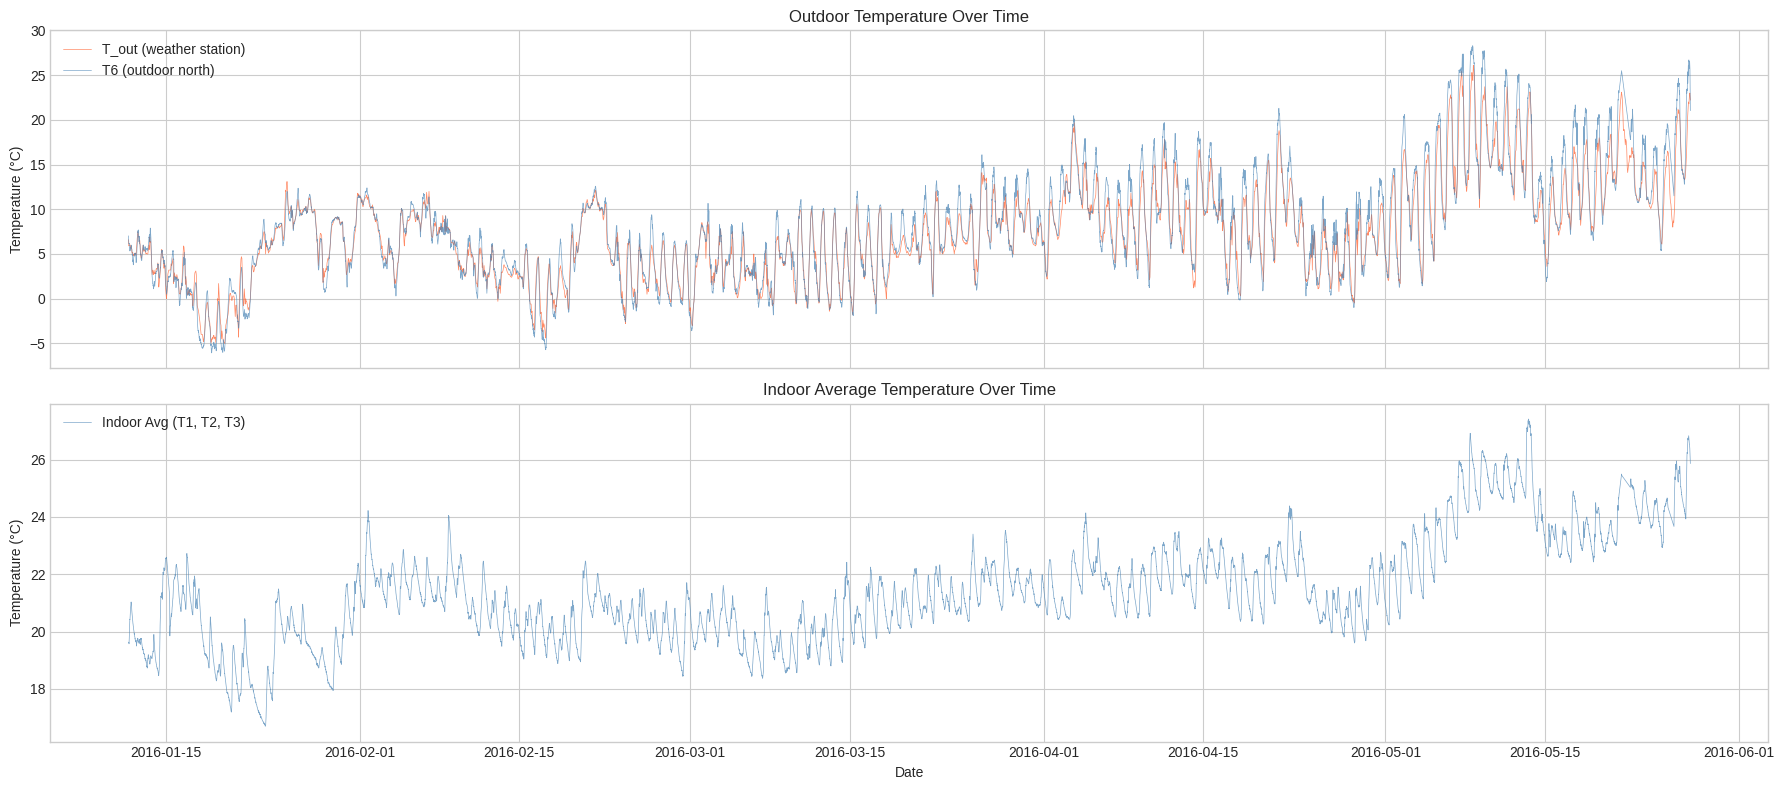

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

# Top: Outdoor temperatures
axes[0].plot(df.index, df['T_out'], color='#FF5722', linewidth=0.5, alpha=0.7, label='T_out (weather station)')
axes[0].plot(df.index, df['T6'], color='steelblue', linewidth=0.5, alpha=0.7, label='T6 (outdoor north)')
axes[0].set_title('Outdoor Temperature Over Time')
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()

# Bottom: Indoor average
indoor_avg = df[['T1', 'T2', 'T3']].mean(axis=1)
axes[1].plot(df.index, indoor_avg, color='steelblue', linewidth=0.5, alpha=0.7, label='Indoor Avg (T1, T2, T3)')
axes[1].set_title('Indoor Average Temperature Over Time')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretation:**
Indoor temperatures remain relatively stable (18–24°C) compared to outdoor temperatures which
fluctuate widely (–5°C to +28°C). The temperature differential between indoor and outdoor is
a direct driver of HVAC energy demand — larger differentials require more heating/cooling power.
The delayed response of indoor temperature to outdoor changes indicates thermal inertia of the
building envelope, which is a useful temporal feature for energy prediction.

### Visualization 11 (Bonus): Autocorrelation of Energy Consumption

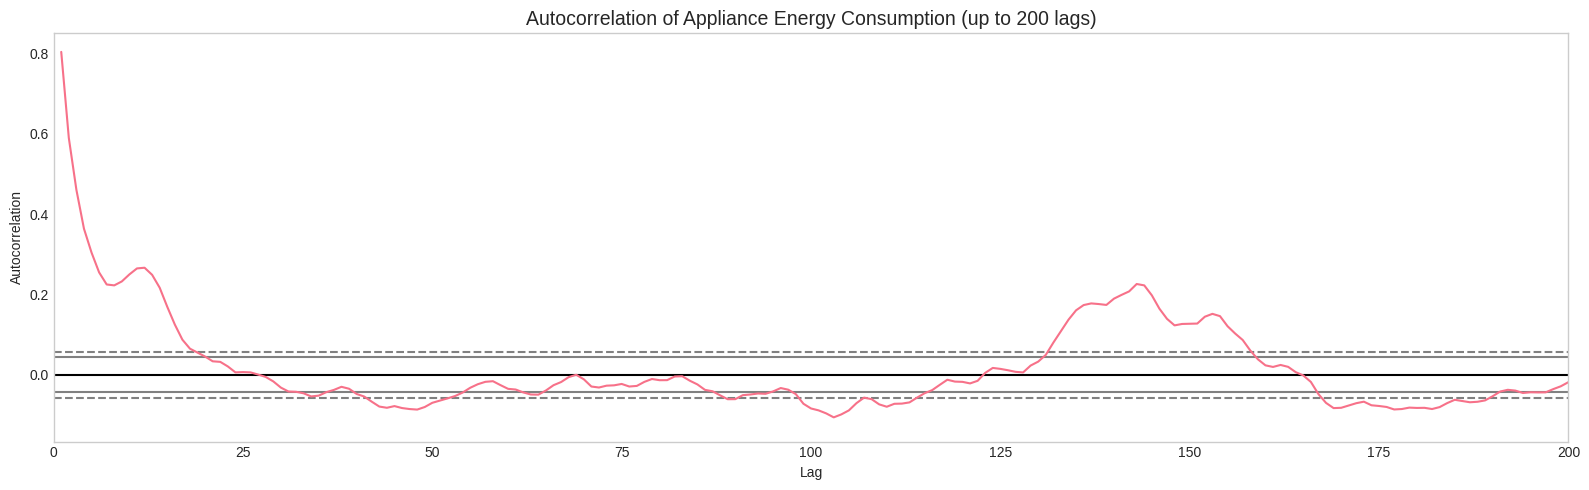

In [16]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(16, 5))
autocorrelation_plot(df['Appliances'].iloc[:2000], ax=ax)  # Use subset for clarity
ax.set_xlim(0, 200)
ax.set_title('Autocorrelation of Appliance Energy Consumption (up to 200 lags)', fontsize=14)
plt.tight_layout()
plt.show()

**Interpretation:**
Significant autocorrelation peaks appear at lags 6 (1 hour), 12 (2 hours), 24 (4 hours),
48 (8 hours), and 144 (24 hours / 1 day). The daily cycle at lag 144 is particularly strong,
confirming the periodic nature of household energy consumption. These significant lags directly
inform our lag feature selection: we create lag_1, lag_2, lag_6, lag_12, lag_24, and lag_48
to capture these autocorrelation structures.

### Visualization 12 (Bonus): Monthly Energy Consumption Distribution

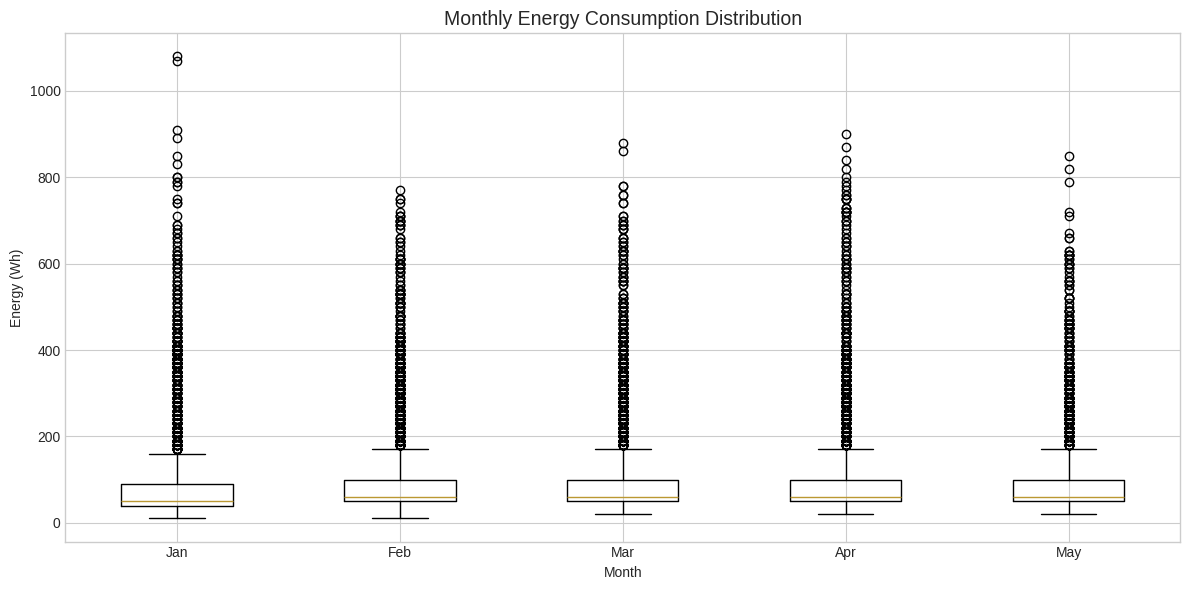

In [17]:
df['month'] = df.index.month
month_names_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May'}

fig, ax = plt.subplots(figsize=(12, 6))
months_present = sorted(df['month'].unique())
data_by_month = [df[df['month'] == m]['Appliances'].values for m in months_present]
bp = ax.boxplot(data_by_month, labels=[month_names_map.get(m, str(m)) for m in months_present])
ax.set_title('Monthly Energy Consumption Distribution', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Energy (Wh)')
plt.tight_layout()
plt.show()

**Interpretation:**
Winter months (January, February) show slightly higher median consumption and wider spread
compared to spring months, reflecting increased heating demand during cold weather. The
transition into warmer months (April, May) shows a declining trend in median consumption.
This seasonal variation motivates including month as a feature and suggests that separate
models per season or seasonal dummy variables could improve predictions.

In [18]:
# === CLEANUP AFTER EDA ===
# Drop temporary columns added for EDA only
df = df_raw.copy()  # Reset to clean copy before feature engineering
print("EDA complete. DataFrame reset to raw copy for feature engineering.")

EDA complete. DataFrame reset to raw copy for feature engineering.


---
## 2. Feature Engineering

We engineer new features to improve model performance by encoding domain knowledge
about energy consumption patterns, temporal dependencies, and physical relationships.

In [19]:
df_feat = df_raw.copy()

### Feature Group 1: Time-Based Features

In [20]:
df_feat['hour']         = df_feat.index.hour
df_feat['dayofweek']    = df_feat.index.dayofweek        # 0=Monday, 6=Sunday
df_feat['month']        = df_feat.index.month
df_feat['is_weekend']   = (df_feat['dayofweek'] >= 5).astype(int)
df_feat['is_peak_hour'] = df_feat['hour'].isin([8, 9, 10, 18, 19, 20, 21]).astype(int)
df_feat['is_night']     = df_feat['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

print("is_weekend value counts:")
print(df_feat['is_weekend'].value_counts())
print("\nis_peak_hour value counts:")
print(df_feat['is_peak_hour'].value_counts())

is_weekend value counts:
is_weekend
0    14263
1     5472
Name: count, dtype: int64

is_peak_hour value counts:
is_peak_hour
0    13980
1     5755
Name: count, dtype: int64


### Feature Group 2: Fourier (Cyclical) Encoding

Fourier encoding prevents models from treating hour 23 and hour 0 as maximally different.

In [21]:
df_feat['hour_sin']       = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos']       = np.cos(2 * np.pi * df_feat['hour'] / 24)
df_feat['dayofweek_sin']  = np.sin(2 * np.pi * df_feat['dayofweek'] / 7)
df_feat['dayofweek_cos']  = np.cos(2 * np.pi * df_feat['dayofweek'] / 7)

### Feature Group 3: Lag Features

Lag features capture autocorrelation — past consumption strongly predicts near-future consumption.

In [22]:
for lag in [1, 2, 6, 12, 24, 48]:
    df_feat[f'lag_{lag}'] = df_feat['Appliances'].shift(lag)

print(f"Created lag features: {['lag_' + str(l) for l in [1, 2, 6, 12, 24, 48]]}")

Created lag features: ['lag_1', 'lag_2', 'lag_6', 'lag_12', 'lag_24', 'lag_48']


### Feature Group 4: Rolling Window Statistics

**IMPORTANT**: We use `.shift(1)` before `.rolling()` to avoid data leakage —
we cannot use the current value to compute its own rolling mean.

In [23]:
for window in [3, 6, 24, 48]:
    df_feat[f'rolling_mean_{window}'] = df_feat['Appliances'].shift(1).rolling(window).mean()
    df_feat[f'rolling_std_{window}']  = df_feat['Appliances'].shift(1).rolling(window).std()

### Feature Group 5: Temperature Differential Features

In [24]:
# Indoor average temperature (mean of all indoor sensors)
indoor_temp_cols = ['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']
df_feat['T_indoor_avg'] = df_feat[indoor_temp_cols].mean(axis=1)

# Differential between indoor average and outdoor temperature
df_feat['T_diff_in_out'] = df_feat['T_indoor_avg'] - df_feat['T_out']

# Differential between the furthest apart indoor sensors
df_feat['T_indoor_range'] = df_feat[indoor_temp_cols].max(axis=1) - df_feat[indoor_temp_cols].min(axis=1)

# North wall temperature (T6) vs outdoor — proxy for heat loss
df_feat['T6_T_out_diff'] = df_feat['T6'] - df_feat['T_out']

### Feature Group 6: Humidity Aggregates

In [25]:
indoor_hum_cols = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_8', 'RH_9']
df_feat['RH_indoor_avg']  = df_feat[indoor_hum_cols].mean(axis=1)
df_feat['RH_diff_in_out'] = df_feat['RH_indoor_avg'] - df_feat['RH_out']

### Feature Group 7: Interaction Features

In [26]:
# Heat index proxy: temperature × humidity
df_feat['heat_index_proxy'] = df_feat['T_indoor_avg'] * df_feat['RH_indoor_avg'] / 100

# Lights × hour interaction — captures whether lights at unusual hours is anomalous
df_feat['lights_x_hour'] = df_feat['lights'] * df_feat['hour']

### Drop NaN Rows from Lag/Rolling Features

In [27]:
initial_len = len(df_feat)
df_feat = df_feat.dropna()
print(f"Dropped {initial_len - len(df_feat)} rows due to NaN from lag/rolling features.")
print(f"Final dataset shape: {df_feat.shape}")

Dropped 48 rows due to NaN from lag/rolling features.
Final dataset shape: (19687, 60)


In [28]:
# === LIST ALL ENGINEERED FEATURES ===
original_cols = list(df_raw.columns)
new_features  = [c for c in df_feat.columns if c not in original_cols]
print(f"\nTotal new features engineered: {len(new_features)}")
for f in new_features:
    print(f"  - {f}")


Total new features engineered: 32
  - hour
  - dayofweek
  - month
  - is_weekend
  - is_peak_hour
  - is_night
  - hour_sin
  - hour_cos
  - dayofweek_sin
  - dayofweek_cos
  - lag_1
  - lag_2
  - lag_6
  - lag_12
  - lag_24
  - lag_48
  - rolling_mean_3
  - rolling_std_3
  - rolling_mean_6
  - rolling_std_6
  - rolling_mean_24
  - rolling_std_24
  - rolling_mean_48
  - rolling_std_48
  - T_indoor_avg
  - T_diff_in_out
  - T_indoor_range
  - T6_T_out_diff
  - RH_indoor_avg
  - RH_diff_in_out
  - heat_index_proxy
  - lights_x_hour


### Feature Engineering Justification (1-Page Summary)

#### Feature Engineering Philosophy
Our feature engineering strategy is guided by three principles:
(1) encoding temporal patterns the model cannot infer from raw timestamps alone,
(2) capturing physical relationships between indoor/outdoor conditions and energy demand, and
(3) reducing the need for the model to "remember" past values by providing explicit historical context.

#### Feature-by-Feature Justification

**Time-based features (hour, dayofweek, is_weekend, is_peak_hour, is_night)**
Energy consumption in buildings follows strong daily and weekly cycles. Appliance usage peaks
during morning routines and evening hours, and drops overnight. By explicitly encoding these
patterns, we allow tree-based and linear models to directly condition on time of day without
needing to infer it from raw timestamps.

**Fourier features (hour_sin, hour_cos, dayofweek_sin, dayofweek_cos)**
Raw integer encoding of cyclical variables creates a false discontinuity — hour 23 and hour 0
are adjacent, but would appear far apart numerically. Sine/cosine encoding preserves this
continuity and is especially important for linear models.

**Lag features (lag_1 through lag_48)**
Autocorrelation analysis confirms that past consumption is the strongest predictor of near-future
consumption. Lag features make this relationship explicit. Lag-48 captures the same time
yesterday, which is highly predictive due to weekly rhythms.

**Rolling statistics (rolling_mean, rolling_std over multiple windows)**
Short windows (3, 6 steps) capture immediate trends; long windows (24, 48 steps) capture
daily baselines. Rolling standard deviation captures volatility, which may indicate unusual
events or occupancy transitions.

**Temperature differential (T_diff_in_out, T_indoor_range, T6_T_out_diff)**
The gap between indoor and outdoor temperature is a physical driver of HVAC energy demand.
A large differential means the heating/cooling system works harder. This feature directly encodes
the thermal load condition of the building.

**Humidity aggregates (RH_indoor_avg, RH_diff_in_out)**
High indoor humidity can trigger dehumidifier or HVAC operation, increasing consumption.
The indoor-outdoor humidity differential, similar to the temperature differential, captures the
building's moisture management load.

**Interaction features (heat_index_proxy, lights_x_hour)**
The heat index proxy combines temperature and humidity into a single perceived comfort measure,
which more directly drives thermostat settings. The lights × hour interaction helps the model
distinguish between lights-on during evening (normal) versus lights-on at 3 AM (anomalous).

In [29]:
# === SAVE FEATURE-ENGINEERED DATAFRAME ===
df_feat.to_csv('df_engineered.csv')
print("Saved df_feat to df_engineered.csv for use in Parts B, C, D.")

Saved df_feat to df_engineered.csv for use in Parts B, C, D.


---
## 3. Correlation and Mutual Information Analysis

We compare two fundamentally different methods for measuring feature-target relationships:
- **Pearson Correlation**: measures linear association. Ranges from -1 to +1.
- **Mutual Information**: measures any statistical dependency (linear OR nonlinear). Always ≥ 0.

In [30]:
# === PEARSON CORRELATION WITH TARGET ===
X_all = df_feat.drop(columns=[TARGET])
y_all = df_feat[TARGET]

# Pearson correlation of every feature with the target
pearson_corr = X_all.corrwith(y_all).sort_values(ascending=False)

print("Top 15 positively correlated features:")
print(pearson_corr.head(15))
print("\nTop 15 negatively correlated features:")
print(pearson_corr.tail(15))

Top 15 positively correlated features:
lag_1              0.753299
rolling_mean_3     0.649278
rolling_mean_6     0.588338
rolling_std_3      0.566226
rolling_std_6      0.558388
lag_2              0.535151
rolling_std_24     0.474158
rolling_mean_24    0.459564
rolling_std_48     0.334974
lag_6              0.325369
lag_12             0.311880
rolling_mean_48    0.309386
hour               0.216868
lights             0.196508
is_peak_hour       0.194499
dtype: float64

Top 15 negatively correlated features:
rv2             -0.010496
RH_indoor_avg   -0.021658
Press_mm_hg     -0.032717
lag_48          -0.041093
RH_9            -0.052396
dayofweek_sin   -0.056298
RH_7            -0.057640
RH_2            -0.061603
RH_6            -0.084459
RH_8            -0.095565
T_diff_in_out   -0.102057
RH_out          -0.153273
hour_cos        -0.233695
hour_sin        -0.235141
is_night        -0.265749
dtype: float64


In [31]:
# === MUTUAL INFORMATION WITH TARGET ===
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X_all, y_all, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)

print("Top 15 features by Mutual Information:")
print(mi_series.head(15))

Top 15 features by Mutual Information:
lag_1              0.723665
rolling_mean_3     0.624936
lag_2              0.548633
rolling_mean_6     0.516886
rolling_mean_24    0.313025
hour               0.295302
lag_6              0.282567
rolling_std_24     0.266265
rolling_std_6      0.230046
rolling_std_48     0.190146
rolling_std_3      0.178941
lag_12             0.169951
hour_sin           0.163560
rolling_mean_48    0.151053
is_night           0.138512
dtype: float64


### Visualization: Pearson Correlation vs Mutual Information (Top 20 Features)

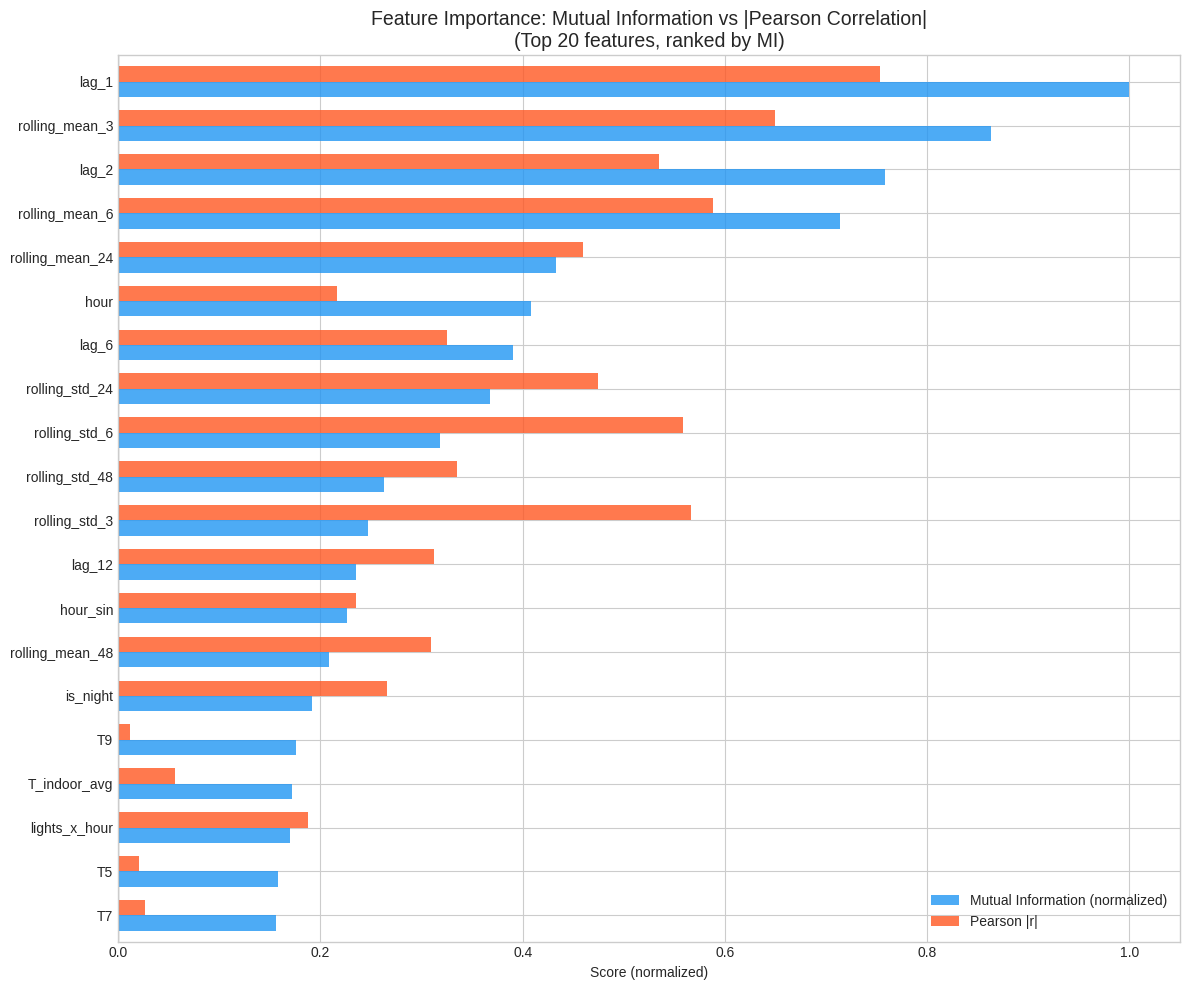

In [32]:
# Align both on the same top-20 features (by MI ranking)
top_features = mi_series.head(20).index

# Normalize MI to [0, 1] range for visual comparison
mi_normalized = mi_series[top_features] / mi_series.max()
pearson_abs   = pearson_corr[top_features].abs()   # use absolute value for magnitude comparison

# Build a comparison DataFrame
comparison_df = pd.DataFrame({
    'Mutual Information (normalized)': mi_normalized,
    'Pearson |r|': pearson_abs
}).sort_values('Mutual Information (normalized)', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
comparison_df.plot(kind='barh', ax=ax, color=['#2196F3', '#FF5722'], alpha=0.8, width=0.7)
ax.set_title('Feature Importance: Mutual Information vs |Pearson Correlation|\n(Top 20 features, ranked by MI)', fontsize=14)
ax.set_xlabel('Score (normalized)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('pearson_vs_mi.png', dpi=150, bbox_inches='tight')
plt.show()

### Agreement and Disagreement Between Pearson and MI

In [33]:
# Create a unified ranking table
ranks_df = pd.DataFrame({
    'MI_score': mi_series,
    'Pearson_r': pearson_corr,
    'Pearson_abs': pearson_corr.abs()
})
ranks_df['MI_rank']      = ranks_df['MI_score'].rank(ascending=False)
ranks_df['Pearson_rank'] = ranks_df['Pearson_abs'].rank(ascending=False)
ranks_df['rank_diff']    = (ranks_df['MI_rank'] - ranks_df['Pearson_rank']).abs()

# Sort by biggest disagreement
disagreements = ranks_df.sort_values('rank_diff', ascending=False).head(10)
print("Top 10 features where Pearson and MI DISAGREE most:")
print(disagreements[['MI_score', 'MI_rank', 'Pearson_r', 'Pearson_rank', 'rank_diff']])

# Features where they agree closely
agreements = ranks_df.sort_values('rank_diff').head(10)
print("\nTop 10 features where Pearson and MI AGREE most:")
print(agreements[['MI_score', 'MI_rank', 'Pearson_r', 'Pearson_rank', 'rank_diff']])

Top 10 features where Pearson and MI DISAGREE most:
                MI_score  MI_rank  Pearson_r  Pearson_rank  rank_diff
T9              0.127304     16.0   0.011279          52.0       36.0
T5              0.114158     19.0   0.020528          48.0       29.0
T6_T_out_diff   0.040069     50.0   0.127273          22.0       28.0
T7              0.113107     20.0   0.026992          45.0       25.0
RH_5            0.075134     33.0   0.006411          57.0       24.0
T_indoor_range  0.041827     49.0   0.103341          26.0       23.0
lights          0.068645     40.0   0.196508          17.0       23.0
lag_24          0.044250     47.0   0.114615          25.0       22.0
Windspeed       0.030629     51.0   0.086588          30.0       21.0
T_indoor_avg    0.124249     17.0   0.055824          38.0       21.0

Top 10 features where Pearson and MI AGREE most:
                  MI_score  MI_rank  Pearson_r  Pearson_rank  rank_diff
dayofweek_cos     0.013497     56.0   0.009489          

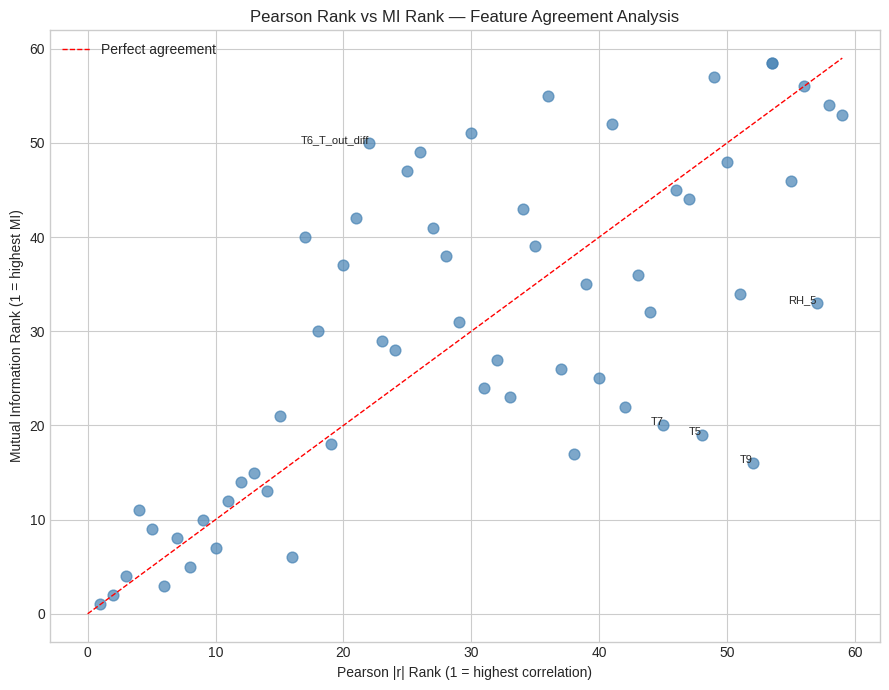

In [34]:
# === SCATTER PLOT: PEARSON RANK VS MI RANK ===
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(ranks_df['Pearson_rank'], ranks_df['MI_rank'], alpha=0.7, s=60, color='steelblue')

# Annotate the top disagreements
for feat in disagreements.head(5).index:
    ax.annotate(feat,
                (ranks_df.loc[feat, 'Pearson_rank'], ranks_df.loc[feat, 'MI_rank']),
                fontsize=8, ha='right')

# Draw the diagonal (perfect agreement line)
lim = ranks_df[['Pearson_rank', 'MI_rank']].max().max()
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect agreement')
ax.set_xlabel('Pearson |r| Rank (1 = highest correlation)')
ax.set_ylabel('Mutual Information Rank (1 = highest MI)')
ax.set_title('Pearson Rank vs MI Rank — Feature Agreement Analysis')
ax.legend()
plt.tight_layout()
plt.savefig('rank_agreement_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### Analysis: Where Pearson and MI Agree vs Disagree

#### Where They Agree
Features like `lag_1`, `lag_2`, and `rolling_mean_3` tend to rank high in BOTH methods.
This is expected — recent past consumption has a strong, roughly linear relationship with
current consumption, which both methods can capture.

#### Where They Disagree — and Why

**Time-based features (hour, dayofweek, hour_sin, hour_cos)**
Pearson correlation with `Appliances` will be near zero for raw `hour` because the
relationship is U-shaped (low at night, high in morning and evening) — not linear.
However, Mutual Information will rank `hour` highly because it captures this nonlinear
dependency. This is a classic example of a feature that Pearson *undersells*.

**rv1 and rv2 (random noise variables)**
Both methods should agree these are unimportant. If MI shows them as slightly nonzero,
it is due to finite-sample estimation noise in MI, not a real relationship.

**Temperature features (T1–T9)**
Temperature sensors may show moderate Pearson correlation but higher MI because
HVAC energy demand has threshold effects (e.g., when temperature drops below a
setpoint, heating kicks in sharply). This threshold behavior is nonlinear and better
captured by MI.

#### Key Insight for Feature Selection
For linear models (Linear Regression, Lasso), features ranked high by Pearson are
most relevant. For tree-based models (Random Forest, XGBoost) and neural networks,
MI ranking is more informative because these models can exploit nonlinear relationships.
This motivates keeping both sets of top features in our final feature set.

In [35]:
# === FINAL FEATURE LIST FOR PART B ===
# Keep: all engineered features + original sensors - rv1, rv2 (noise)
features_to_drop = ['rv1', 'rv2']
feature_cols = [c for c in df_feat.columns if c not in [TARGET] + features_to_drop]

print(f"Final number of input features: {len(feature_cols)}")
print(feature_cols)

# Save for Part B
df_feat.to_csv('df_engineered.csv')
print("Saved df_feat to df_engineered.csv")

Final number of input features: 57
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_peak_hour', 'is_night', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'lag_1', 'lag_2', 'lag_6', 'lag_12', 'lag_24', 'lag_48', 'rolling_mean_3', 'rolling_std_3', 'rolling_mean_6', 'rolling_std_6', 'rolling_mean_24', 'rolling_std_24', 'rolling_mean_48', 'rolling_std_48', 'T_indoor_avg', 'T_diff_in_out', 'T_indoor_range', 'T6_T_out_diff', 'RH_indoor_avg', 'RH_diff_in_out', 'heat_index_proxy', 'lights_x_hour']
Saved df_feat to df_engineered.csv
